In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
df = pd.read_csv('mental_health_lifestyle_2000.csv')
df.head()

,Person_ID,Age,Gender,Occupation,Daily_Screen_Time,Social_Media_Usage,Night_Usage,Sleep_Hours,Stress_Level,Work_Study_Hours,Physical_Activity,Social_Interaction_Score,Caffeine_Intake,Smoking,Alcohol,Depression,Anxiety,Burnout
0,1,54,Male,Student,10.2,7.5,0,6.5,8,5.8,Low,6,2,0,1,1,1,1
1,2,44,Male,Student,6.8,4.5,0,5.1,4,7.9,High,2,1,1,0,0,0,0
2,3,30,Male,Employed,5.5,6.9,0,3.5,10,9.4,Low,2,0,1,1,1,0,1
3,4,58,Male,Employed,5.6,4.1,0,9.0,2,2.0,High,10,0,0,1,0,0,0
4,5,23,Female,Employed,10.1,6.0,1,3.8,4,4.6,Low,4,4,0,1,1,1,0


In [4]:
df.shape

(2000, 18)

In [5]:
df.columns

Index(['Person_ID', 'Age', 'Gender', 'Occupation', 'Daily_Screen_Time',
       'Social_Media_Usage', 'Night_Usage', 'Sleep_Hours', 'Stress_Level',
       'Work_Study_Hours', 'Physical_Activity', 'Social_Interaction_Score',
       'Caffeine_Intake', 'Smoking', 'Alcohol', 'Depression', 'Anxiety',
       'Burnout'],
      dtype='object')

In [6]:
df. info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Person_ID                 2000 non-null   int64  
 1   Age                       2000 non-null   int64  
 2   Gender                    2000 non-null   object 
 3   Occupation                2000 non-null   object 
 4   Daily_Screen_Time         2000 non-null   float64
 5   Social_Media_Usage        2000 non-null   float64
 6   Night_Usage               2000 non-null   int64  
 7   Sleep_Hours               2000 non-null   float64
 8   Stress_Level              2000 non-null   int64  
 9   Work_Study_Hours          2000 non-null   float64
 10  Physical_Activity         2000 non-null   object 
 11  Social_Interaction_Score  2000 non-null   int64  
 12  Caffeine_Intake           2000 non-null   int64  
 13  Smoking                   2000 non-null   int64  
 14  Alcohol 

In [7]:
df.isnull().sum()

Person_ID                   0
Age                         0
Gender                      0
Occupation                  0
Daily_Screen_Time           0
Social_Media_Usage          0
Night_Usage                 0
Sleep_Hours                 0
Stress_Level                0
Work_Study_Hours            0
Physical_Activity           0
Social_Interaction_Score    0
Caffeine_Intake             0
Smoking                     0
Alcohol                     0
Depression                  0
Anxiety                     0
Burnout                     0
dtype: int64

In [8]:
df.describe()

,Person_ID,Age,Daily_Screen_Time,Social_Media_Usage,Night_Usage,Sleep_Hours,Stress_Level,Work_Study_Hours,Social_Interaction_Score,Caffeine_Intake,Smoking,Alcohol,Depression,Anxiety,Burnout
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,37.694000,6.943150,4.436400,0.489500,6.00765,5.409500,7.005650,5.488000,2.029500,0.492000,0.513000,0.499000,0.505500,0.515500
std,577.494589,12.614195,2.882415,2.011725,0.500015,1.70631,2.885129,2.846442,2.885484,1.432709,0.500061,0.499956,0.500124,0.500095,0.499885
min,1.000000,16.000000,2.000000,1.000000,0.000000,3.00000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,500.750000,27.000000,4.500000,2.700000,0.000000,4.60000,3.000000,4.500000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1000.500000,38.000000,6.800000,4.400000,0.000000,6.00000,5.000000,7.100000,6.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.000000
75%,1500.250000,49.000000,9.400000,6.200000,1.000000,7.50000,8.000000,9.400000,8.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,2000.000000,59.000000,12.000000,8.000000,1.000000,9.00000,10.000000,12.000000,10.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000


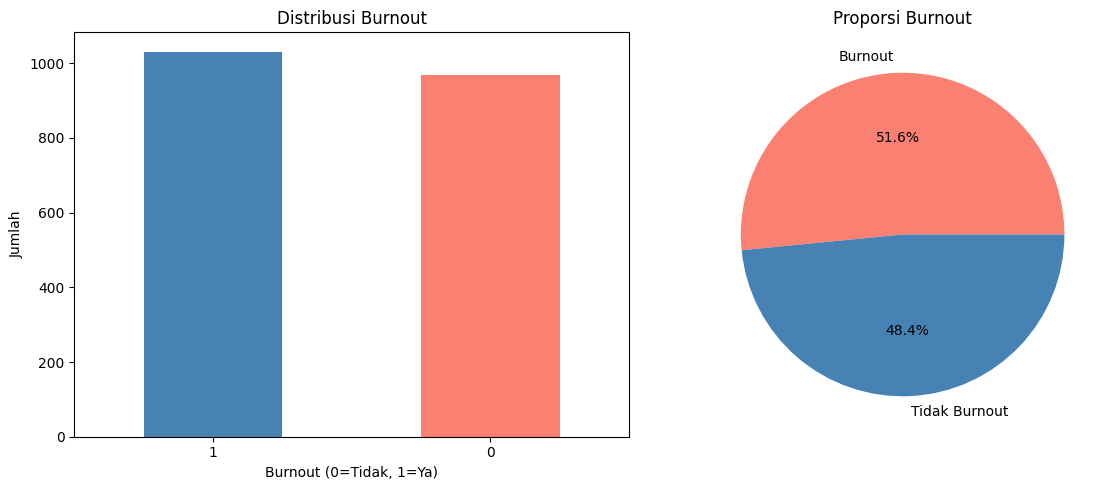

Burnout
1    1031
0     969
Name: count, dtype: int64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
df['Burnout'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Distribusi Burnout')
axes[0].set_xlabel('Burnout (0=Tidak, 1=Ya)')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(rotation=0)

# Pie chart
df['Burnout'].value_counts().plot(kind='pie', ax=axes[1], 
    labels=['Burnout', 'Tidak Burnout'], autopct='%1.1f%%',
    colors=['salmon', 'steelblue'])
axes[1].set_title('Proporsi Burnout')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print(df['Burnout'].value_counts())

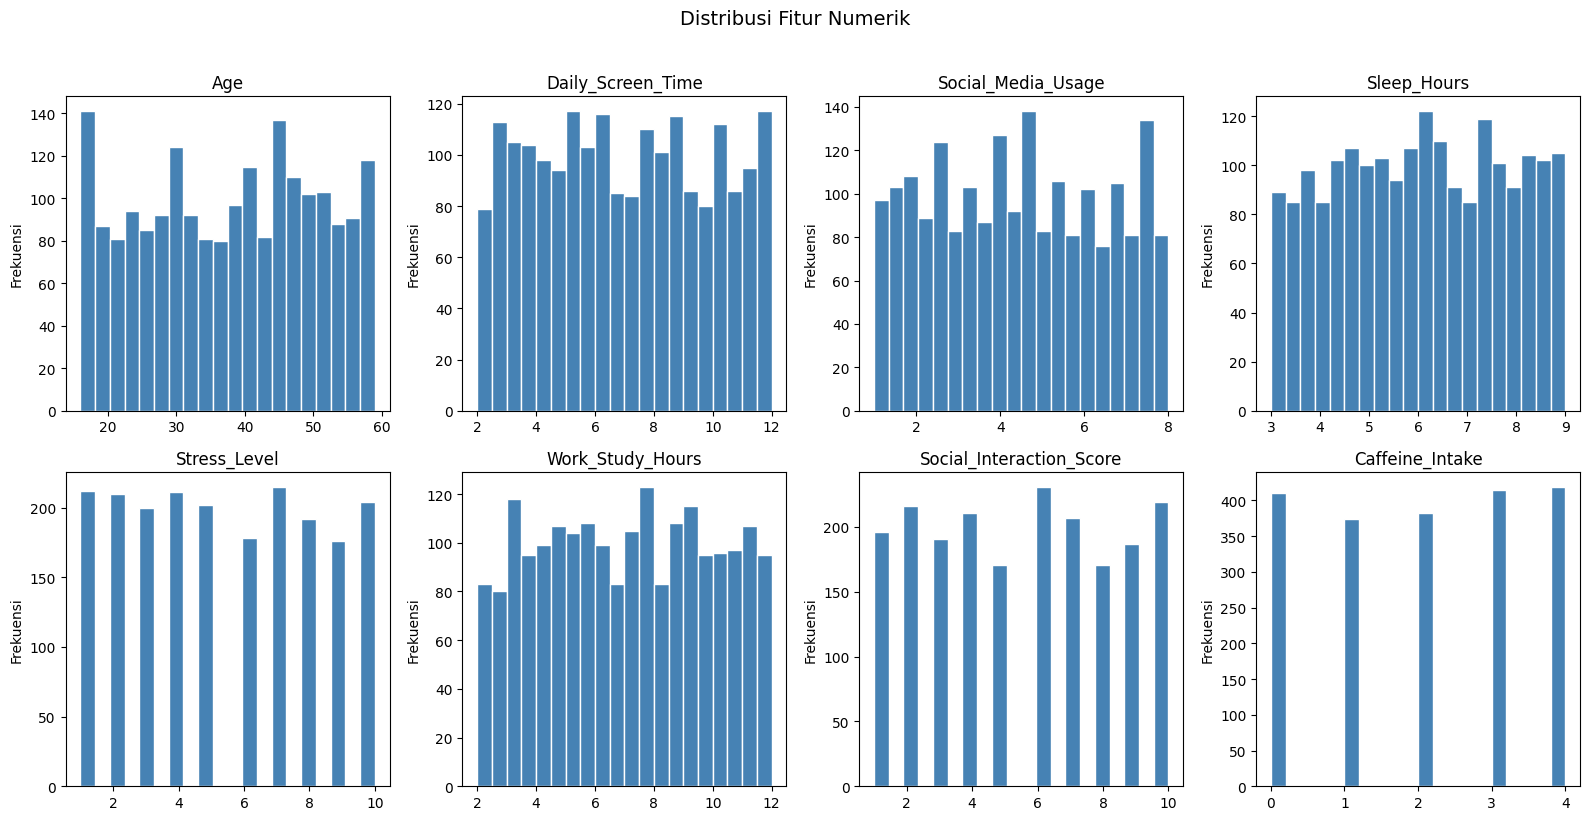

In [10]:
num_cols = ['Age', 'Daily_Screen_Time', 'Social_Media_Usage', 
            'Sleep_Hours', 'Stress_Level', 'Work_Study_Hours', 
            'Social_Interaction_Score', 'Caffeine_Intake']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_ylabel('Frekuensi')

plt.suptitle('Distribusi Fitur Numerik', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

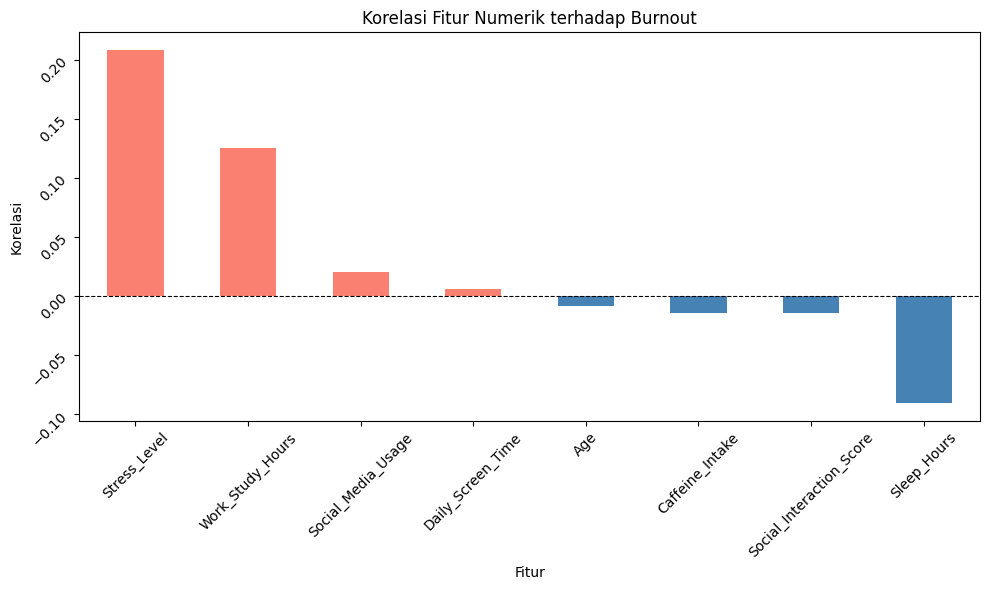

Stress_Level                0.208394
Work_Study_Hours            0.125046
Social_Media_Usage          0.020282
Daily_Screen_Time           0.006462
Age                        -0.008609
Caffeine_Intake            -0.014259
Social_Interaction_Score   -0.014611
Sleep_Hours                -0.090605
dtype: float64


In [11]:
num_cols = ['Age', 'Daily_Screen_Time', 'Social_Media_Usage', 
            'Sleep_Hours', 'Stress_Level', 'Work_Study_Hours', 
            'Social_Interaction_Score', 'Caffeine_Intake']

correlations = df[num_cols].corrwith(df['Burnout']).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
correlations.plot(kind='bar', color=['salmon' if x > 0 else 'steelblue' for x in correlations])
plt.title('Korelasi Fitur Numerik terhadap Burnout')
plt.xlabel('Fitur')
plt.ylabel('Korelasi')
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.tick_params(rotation=45)
plt.tight_layout()
plt.show()

print(correlations)

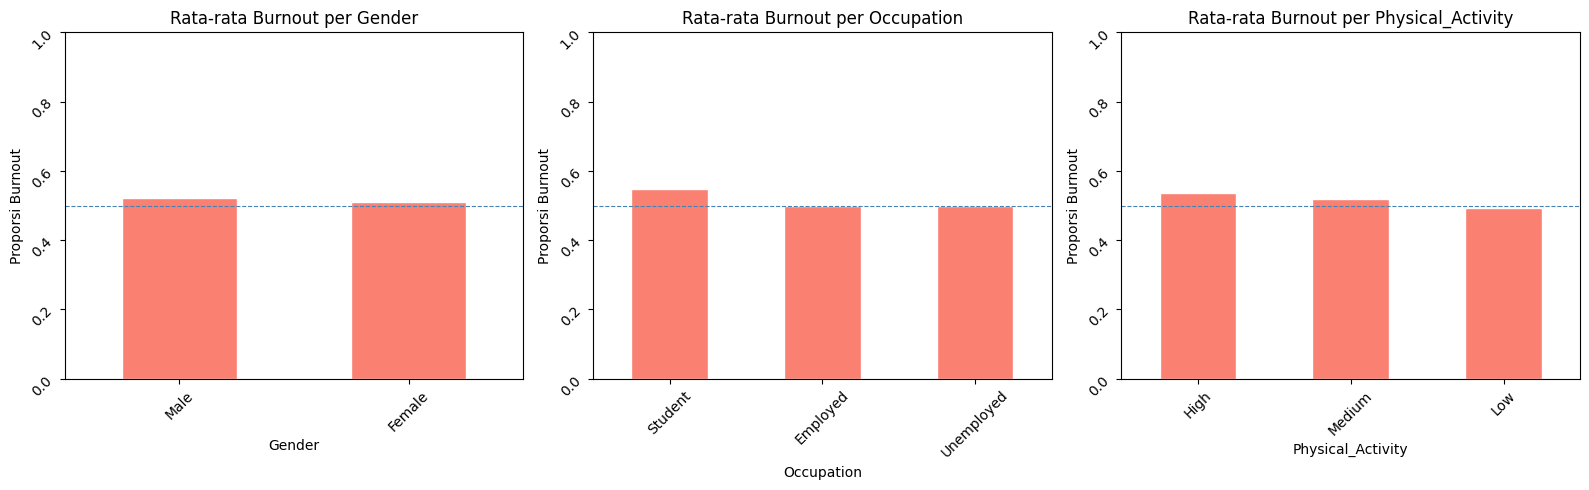

In [12]:
cat_cols = ['Gender', 'Occupation', 'Physical_Activity']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(cat_cols):
    burnout_pct = df.groupby(col)['Burnout'].mean().sort_values(ascending=False)
    burnout_pct.plot(kind='bar', ax=axes[i], color='salmon', edgecolor='white')
    axes[i].set_title(f'Rata-rata Burnout per {col}')
    axes[i].set_ylabel('Proporsi Burnout')
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(rotation=45)
    axes[i].axhline(y=0.5, color='steelblue', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

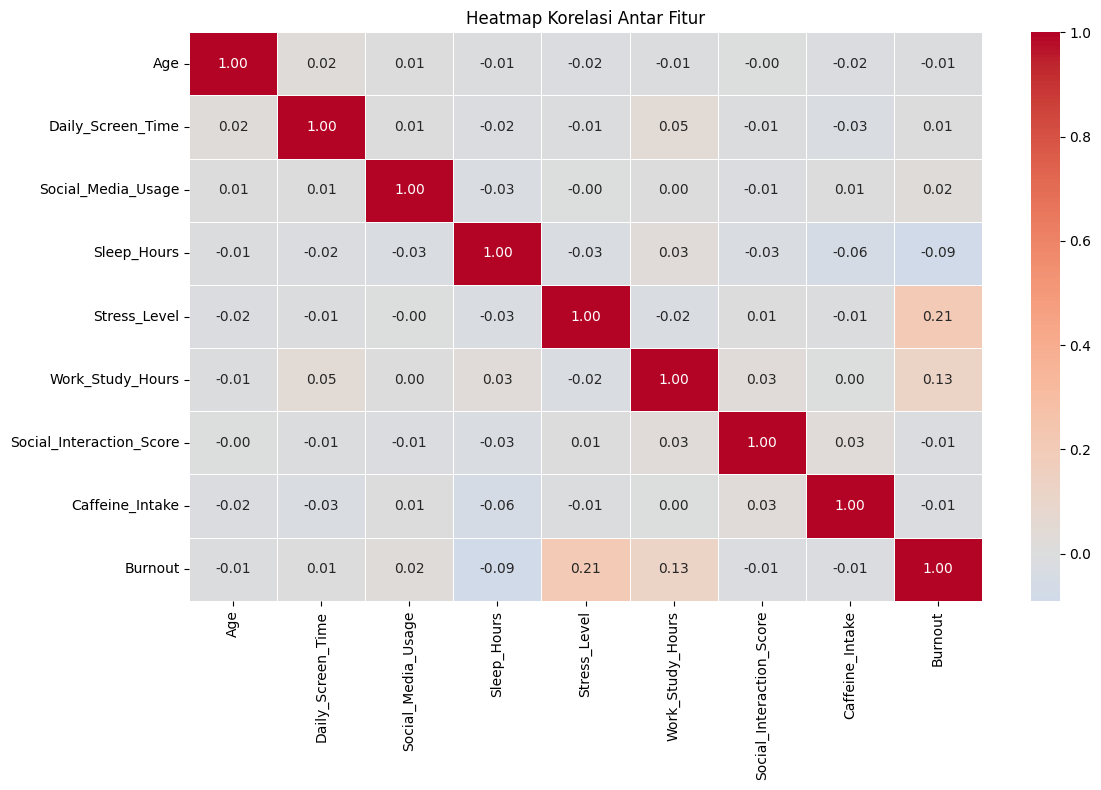

In [13]:
num_cols = ['Age', 'Daily_Screen_Time', 'Social_Media_Usage', 
            'Sleep_Hours', 'Stress_Level', 'Work_Study_Hours', 
            'Social_Interaction_Score', 'Caffeine_Intake', 'Burnout']

plt.figure(figsize=(12, 8))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur')
plt.tight_layout()
plt.show()

In [14]:
cat_cols = ['Gender', 'Occupation', 'Physical_Activity']

for col in cat_cols:
    print(f"{col}: {df[col].unique()}")
    print(f"  Jumlah unik: {df[col].nunique()}\n")

Gender: ['Male' 'Female']
  Jumlah unik: 2

Occupation: ['Student' 'Employed' 'Unemployed']
  Jumlah unik: 3

Physical_Activity: ['Low' 'High' 'Medium']
  Jumlah unik: 3

